In [ ]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('challenges-in-representation-learning-facial-expression-recognition-challenge')

100%|██████████| 285M/285M [00:01<00:00, 225MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tarfile
import zipfile

# Dataset Import

In [ ]:
print("--- Searching Downloaded Path ---")
for root, dirs, files in os.walk(path):
    for file in files:
        print(f"Found: {os.path.join(root, file)}")

--- Searching Downloaded Path ---
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv
Found: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv


In [ ]:
for root, dirs, files in os.walk(path):
    for file in files:
        file_path = os.path.join(root, file)
        if file.endswith('.tar.gz') or file.endswith('.tgz'):
            print(f"\nExtracting archive: {file}...")
            with tarfile.open(file_path, "r:gz") as tar:
                tar.extractall(path=root)
        elif file.endswith('.zip'):
            print(f"\nExtracting archive: {file}...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(root)


Extracting archive: fer2013.tar.gz...


/tmp/ipykernel_1185/3244132510.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=root)


In [ ]:
csv_file = None

# Prioritize finding 'train.csv' or 'icml_face_data.csv' as the main dataset
for root, dirs, files in os.walk(path):
    if 'train.csv' in files:
        csv_file = os.path.join(root, 'train.csv')
        break
    elif 'icml_face_data.csv' in files:
        csv_file = os.path.join(root, 'icml_face_data.csv')
        break

if csv_file is None:
    print("\nError: Could not find a suitable main dataset file (e.g., train.csv or icml_face_data.csv) in the downloaded path.")
else:
    print(f"\n--- Loading Dataset from: {csv_file} ---")
    df = pd.read_csv(csv_file)


--- Loading Dataset from: /root/.cache/kagglehub/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv ---


# Dataset Analysis

Dataset Shape (Rows, Columns): (28709, 2)


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


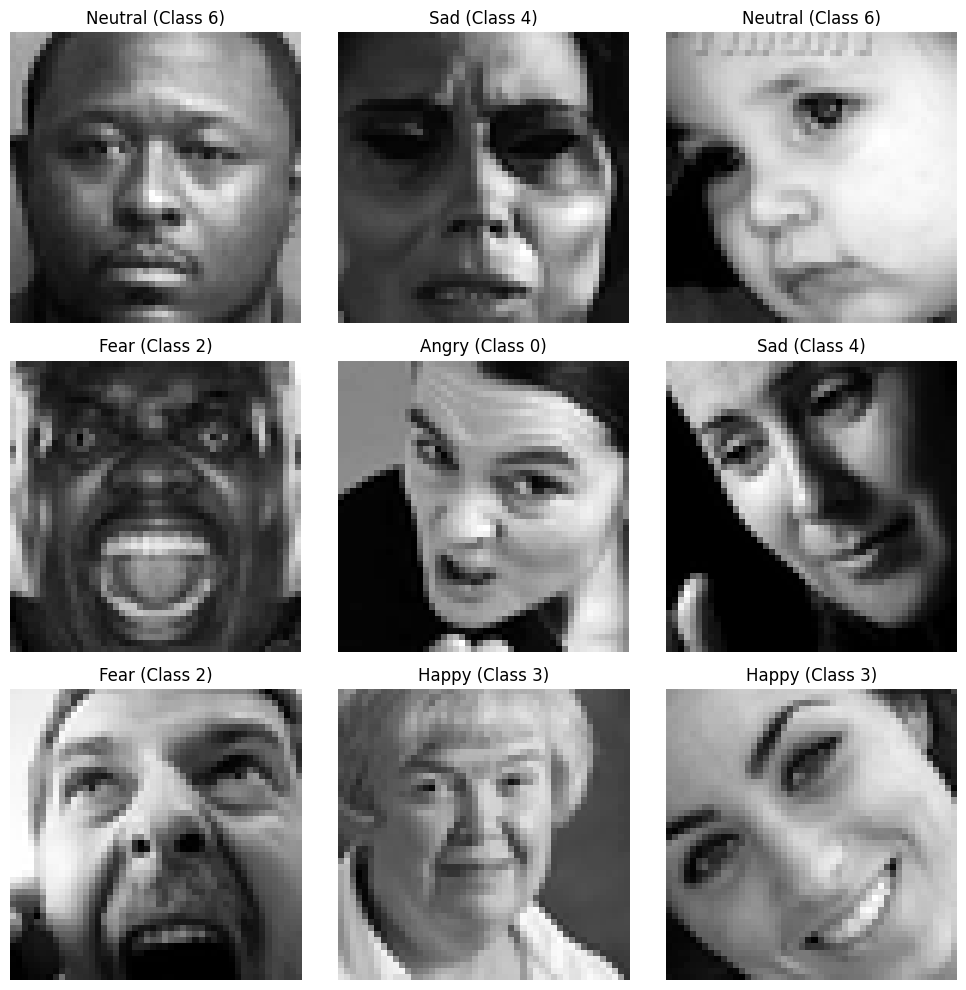

In [ ]:
    print(f"Dataset Shape (Rows, Columns): {df.shape}")
    display(df.head())

    emotion_dict = {
        0: 'Angry', 1: 'Disgust', 2: 'Fear',
        3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'
    }

    plt.figure(figsize=(10, 10))

    sample_df = df.sample(9, random_state=42).reset_index(drop=True)

    for i, row in sample_df.iterrows():
        pixels_array = np.array(row['pixels'].split(), dtype='float32')

        image = pixels_array.reshape(48, 48)

        plt.subplot(3, 3, i + 1)
        plt.imshow(image, cmap='gray')

        label_col = 'emotion' if 'emotion' in df.columns else df.columns[0]
        emotion_id = row[label_col]
        emotion_label = emotion_dict.get(emotion_id, "Unknown")

        plt.title(f"{emotion_label} (Class {emotion_id})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
    if 'emotion' in df.columns:
        distribution = df['emotion'].value_counts().rename(index=emotion_dict)
        print(distribution)

emotion
Happy       7215
Neutral     4965
Sad         4830
Fear        4097
Angry       3995
Surprise    3171
Disgust      436
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['emotion'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Test Samples: {len(test_df)}")

Training Samples: 22967
Validation Samples: 2871
Test Samples: 2871


# Dataset Augmentation

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixel_string = self.df.iloc[idx]['pixels']
        pixels = np.array(pixel_string.split(), dtype=np.uint8)
        image = pixels.reshape(48, 48)

        image = Image.fromarray(image).convert('RGB')

        label_col = 'emotion' if 'emotion' in self.df.columns else self.df.columns[0]
        label = int(self.df.iloc[idx][label_col])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import torchvision.transforms as T

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2), # Added ColorJitter
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.ToTensor(),
    normalize,
    T.RandomErasing(p=0.3, scale=(0.02, 0.1)),
])

val_test_transforms = T.Compose([
    T.ToTensor(),
    normalize,
])

In [ ]:
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_test_transforms)
test_dataset = FERDataset(test_df, transform=val_test_transforms)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total Batches in train_loader: {len(train_loader)} (at batch size {batch_size})")
print(f"Total Batches in val_loader: {len(val_loader)}")


images, labels = next(iter(train_loader))
print(f"\nBatch Image Shape: {images.shape}")
print(f"Batch Label Shape: {labels.shape}")

Total Batches in train_loader: 359 (at batch size 64)
Total Batches in val_loader: 45

Batch Image Shape: torch.Size([64, 3, 48, 48])
Batch Label Shape: torch.Size([64])


Class weights for the unbalanced dataset

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = train_df['emotion'].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class Weights:", weights_tensor.cpu().numpy())

Class Weights: [1.0265957 9.401146  1.0012206 0.5684338 0.8491201 1.2932597 0.8260322]


In [ ]:
def test_single_batch_overfit(model, train_loader, device='cpu'):
    print("\n--- Starting Single Batch Overfit Test ---")
    model.to(device)

    model.train()

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)

    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)

    print(f"Testing on a single batch of {images.size(0)} images.")

    epochs = 200
    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        accuracy = 100 * correct / labels.size(0)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:03d}/{epochs}] | Loss: {loss.item():.4f} | Accuracy: {accuracy:.2f}%")

    if loss.item() < 0.1 and accuracy == 100.0:
        print("\nSUCCESS: The model successfully overfitted the batch")
    else:
        print("\nFAILURE: The model failed to overfit")

# Model Setup

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

def get_resnet_model(num_classes=7, dropout_rate=0.5):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

# --- Sanity check ---
model = get_resnet_model()
dummy = torch.zeros(4, 3, 48, 48)
out = model(dummy)
print(f"ResNet18 initialized — params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Output shape: {out.shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


ResNet18 initialized — params: 11,180,103
Output shape: torch.Size([4, 7])


In [ ]:
test_single_batch_overfit(model, train_loader, device)

In [ ]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.RandomErasing(p=0.3, scale=(0.02, 0.1)),
])

val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

# Training

In [ ]:
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import copy

fer_classes = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

dataset_sizes = {
    'train': len(train_df),
    'val': len(val_df)
}

def train_once():
    # --- 1. CONFIGURATION ---
    config = {
      "learning_rate":  1e-3,
      "weight_decay":   1e-2,
      "batch_size":     64,
      "dropout_rate":   0.5,
      "epochs":         40,
      "label_smoothing": 0.1
    }

    wandb.init(project="facial-expression-recognition", config=config)

    # --- 2. MODEL, LOSS, OPTIMIZER, SCHEDULER ---
    model = get_resnet_model(dropout_rate=config["dropout_rate"]).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=config["label_smoothing"])

    optimizer = optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])

    wandb.watch(model, criterion, log="all", log_freq=10)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # --- 3. TRAINING LOOP ---
    for epoch in range(config["epochs"]):
        print(f'Epoch {epoch + 1}/{config["epochs"]}')
        print('-' * 10)

        # ---------- TRAINING PHASE ----------
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            running_train_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_train_loss / dataset_sizes['train']
        epoch_train_acc = running_train_corrects.double() / dataset_sizes['train']

        # ---------- VALIDATION PHASE ----------
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0

        all_val_targets = []
        all_val_preds = []
        all_val_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                running_val_loss += loss.item() * inputs.size(0)
                running_val_corrects += torch.sum(preds == labels.data)

                all_val_targets.extend(labels.cpu().numpy())
                all_val_preds.extend(preds.cpu().numpy())
                all_val_probs.extend(probs.cpu().numpy())

        epoch_val_loss = running_val_loss / dataset_sizes['val']
        epoch_val_acc = running_val_corrects.double() / dataset_sizes['val']

        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        # ---------- WANDB LOGGING ----------
        wandb.log({
            "epoch": epoch,
            "train_loss": epoch_train_loss,
            "train_acc": epoch_train_acc,
            "val_loss": epoch_val_loss,
            "val_acc": epoch_val_acc,
            "learning_rate": optimizer.param_groups[0]['lr'],

            # Confusion Matrix
            "confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=all_val_targets,
                preds=all_val_preds,
                class_names=fer_classes
            ),

            # ROC Curve
            "roc_curve": wandb.plot.roc_curve(
                y_true=all_val_targets,
                y_probas=all_val_probs,
                labels=fer_classes
            ),

            # Precision-Recall Curve
            "pr_curve": wandb.plot.pr_curve(
                y_true=all_val_targets,
                y_probas=all_val_probs,
                labels=fer_classes
            )
        })

        scheduler.step()

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_fer_model.pth')
            print(">>> Saved new best model!")

    print(f'\nTraining complete. Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    wandb.finish()

    return model

best_model = train_once()

Epoch 1/40
----------
Train Loss: 2.1821 Acc: 0.1971
Val Loss:   2.1395 Acc: 0.2375
>>> Saved new best model!
Epoch 2/40
----------
Train Loss: 1.9958 Acc: 0.2928
Val Loss:   1.8334 Acc: 0.3675
>>> Saved new best model!
Epoch 3/40
----------
Train Loss: 1.9013 Acc: 0.3527
Val Loss:   1.8261 Acc: 0.3891
>>> Saved new best model!
Epoch 4/40
----------
Train Loss: 1.8543 Acc: 0.3827
Val Loss:   1.7647 Acc: 0.4709
>>> Saved new best model!
Epoch 5/40
----------
Train Loss: 1.8011 Acc: 0.4283
Val Loss:   1.6829 Acc: 0.5037
>>> Saved new best model!
Epoch 6/40
----------
Train Loss: 1.7821 Acc: 0.4425
Val Loss:   1.6849 Acc: 0.4852
Epoch 7/40
----------
Train Loss: 1.7549 Acc: 0.4590
Val Loss:   1.7118 Acc: 0.4929
Epoch 8/40
----------
Train Loss: 1.7627 Acc: 0.4612
Val Loss:   1.6878 Acc: 0.5099
>>> Saved new best model!
Epoch 9/40
----------
Train Loss: 1.7160 Acc: 0.4837
Val Loss:   1.6472 Acc: 0.5357
>>> Saved new best model!
Epoch 10/40
----------
Train Loss: 1.7060 Acc: 0.4904
Val Loss

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
train_acc,▁▂▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▆▅▅▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇▇█▇██████████████
val_loss,█▅▅▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,39
learning_rate,0.0
train_acc,0.6431
train_loss,1.41936
val_acc,0.63636
